<a href="https://www.kaggle.com/code/sonawanelalitsunil/learning-styles-academic-success-100-ml?scriptVersionId=224372447" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-performance-and-learning-style/student_performance_large_dataset.csv


## Title:
## "Analyzing Student Performance: The Impact of Learning Styles on Academic Success"

## 📖 Project Description 
## 🔹 Introduction
**Understanding student performance is essential in education. This project explores how different learning styles impact academic success by analyzing student performance data. The goal is to identify patterns, correlations, and insights that can help educators optimize teaching strategies.**


🔹 Objectives

✅ Identify key factors affecting student performance.

✅ Analyze the relationship between learning styles and academic success.

✅ Use data visualization to uncover hidden trends.

✅ Apply machine learning models to predict student performance.

🔹 Dataset Overview

The dataset includes student performance metrics such as:

✔ Demographic data (Age, Gender, School Type)

✔ Learning styles (Visual, Auditory, Kinesthetic)

✔ Study habits (Study Hours, Classroom Participation, Homework Completion)

✔ Academic performance (Grades, Test Scores)

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/student-performance-and-learning-style/student_performance_large_dataset.csv")

In [4]:
df.head()

,Student_ID,Age,Gender,Study_Hours_per_Week,Preferred_Learning_Style,Online_Courses_Completed,Participation_in_Discussions,Assignment_Completion_Rate (%),Exam_Score (%),Attendance_Rate (%),Use_of_Educational_Tech,Self_Reported_Stress_Level,Time_Spent_on_Social_Media (hours/week),Sleep_Hours_per_Night,Final_Grade
0,S00001,18,Female,48,Kinesthetic,14,Yes,100,69,66,Yes,High,9,8,C
1,S00002,29,Female,30,Reading/Writing,20,No,71,40,57,Yes,Medium,28,8,D
2,S00003,20,Female,47,Kinesthetic,11,No,60,43,79,Yes,Low,13,7,D
3,S00004,23,Female,13,Auditory,0,Yes,63,70,60,Yes,Low,24,10,B
4,S00005,19,Female,24,Auditory,19,Yes,59,63,93,Yes,Medium,26,8,C


In [5]:
df.tail()

,Student_ID,Age,Gender,Study_Hours_per_Week,Preferred_Learning_Style,Online_Courses_Completed,Participation_in_Discussions,Assignment_Completion_Rate (%),Exam_Score (%),Attendance_Rate (%),Use_of_Educational_Tech,Self_Reported_Stress_Level,Time_Spent_on_Social_Media (hours/week),Sleep_Hours_per_Night,Final_Grade
9995,S09996,20,Male,30,Auditory,6,Yes,62,58,76,Yes,Medium,17,6,C
9996,S09997,23,Female,16,Visual,8,Yes,54,84,86,Yes,Medium,6,5,B
9997,S09998,26,Male,23,Visual,3,Yes,54,40,70,No,Medium,20,8,D
9998,S09999,18,Male,41,Reading/Writing,7,Yes,66,45,90,Yes,Low,6,8,D
9999,S10000,24,Male,8,Visual,20,Yes,87,40,81,No,High,17,4,D


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Student_ID                               10000 non-null  object
 1   Age                                      10000 non-null  int64 
 2   Gender                                   10000 non-null  object
 3   Study_Hours_per_Week                     10000 non-null  int64 
 4   Preferred_Learning_Style                 10000 non-null  object
 5   Online_Courses_Completed                 10000 non-null  int64 
 6   Participation_in_Discussions             10000 non-null  object
 7   Assignment_Completion_Rate (%)           10000 non-null  int64 
 8   Exam_Score (%)                           10000 non-null  int64 
 9   Attendance_Rate (%)                      10000 non-null  int64 
 10  Use_of_Educational_Tech                  10000 non-null  ob

In [7]:
df.shape

(10000, 15)

In [8]:
df.describe()

,Age,Study_Hours_per_Week,Online_Courses_Completed,Assignment_Completion_Rate (%),Exam_Score (%),Attendance_Rate (%),Time_Spent_on_Social_Media (hours/week),Sleep_Hours_per_Night
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,23.478800,27.130300,10.007900,74.922000,70.188900,75.085100,14.936500,6.979300
std,3.461986,13.002547,6.136726,14.675437,17.649447,14.749251,9.022639,1.996965
min,18.000000,5.000000,0.000000,50.000000,40.000000,50.000000,0.000000,4.000000
25%,20.000000,16.000000,5.000000,62.000000,55.000000,62.000000,7.000000,5.000000
50%,23.000000,27.000000,10.000000,75.000000,70.000000,75.000000,15.000000,7.000000
75%,27.000000,38.000000,15.000000,88.000000,85.000000,88.000000,23.000000,9.000000
max,29.000000,49.000000,20.000000,100.000000,100.000000,100.000000,30.000000,10.000000


In [9]:
df.isnull().sum()

Student_ID                                 0
Age                                        0
Gender                                     0
Study_Hours_per_Week                       0
Preferred_Learning_Style                   0
Online_Courses_Completed                   0
Participation_in_Discussions               0
Assignment_Completion_Rate (%)             0
Exam_Score (%)                             0
Attendance_Rate (%)                        0
Use_of_Educational_Tech                    0
Self_Reported_Stress_Level                 0
Time_Spent_on_Social_Media (hours/week)    0
Sleep_Hours_per_Night                      0
Final_Grade                                0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [11]:
df.corr

<bound method DataFrame.corr of      Student_ID  Age  Gender  Study_Hours_per_Week Preferred_Learning_Style  \
0        S00001   18  Female                    48              Kinesthetic   
1        S00002   29  Female                    30          Reading/Writing   
2        S00003   20  Female                    47              Kinesthetic   
3        S00004   23  Female                    13                 Auditory   
4        S00005   19  Female                    24                 Auditory   
...         ...  ...     ...                   ...                      ...   
9995     S09996   20    Male                    30                 Auditory   
9996     S09997   23  Female                    16                   Visual   
9997     S09998   26    Male                    23                   Visual   
9998     S09999   18    Male                    41          Reading/Writing   
9999     S10000   24    Male                     8                   Visual   

      Online_Course

In [12]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Study_Hours_per_Week',
       'Preferred_Learning_Style', 'Online_Courses_Completed',
       'Participation_in_Discussions', 'Assignment_Completion_Rate (%)',
       'Exam_Score (%)', 'Attendance_Rate (%)', 'Use_of_Educational_Tech',
       'Self_Reported_Stress_Level', 'Time_Spent_on_Social_Media (hours/week)',
       'Sleep_Hours_per_Night', 'Final_Grade'],
      dtype='object')

In [13]:
categorical_columns = ['Student_ID', 'Gender', 'Preferred_Learning_Style', 'Participation_in_Discussions', 'Use_of_Educational_Tech', 'Self_Reported_Stress_Level', 'Final_Grade']

In [14]:
df['Final_Grade'] = df['Final_Grade'].astype(str).str.strip()

In [15]:
# Ensure all categorical columns exist in df
categorical_columns = [col for col in categorical_columns if col in df.columns]

# Convert to categorical dtype
for col in categorical_columns:
    df[col] = df[col].astype("category")


In [16]:
print('\nUnique values for Final_Grade:')
print(df['Final_Grade'].unique())


Unique values for Final_Grade:
['C', 'D', 'B', 'A']
Categories (4, object): ['A', 'B', 'C', 'D']


## Data Visulization

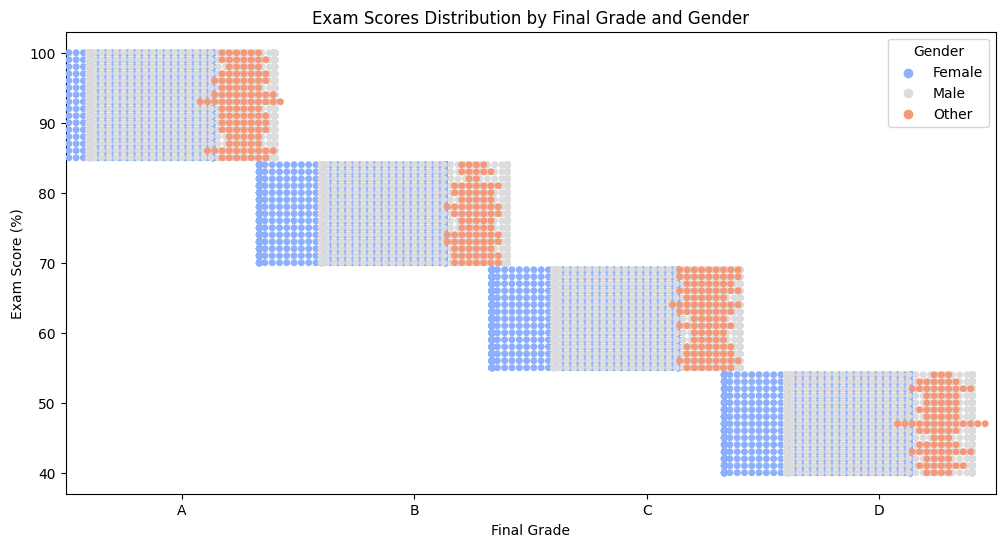

In [17]:
plt.figure(figsize=(12, 6))
sns.swarmplot(x='Final_Grade', y='Exam_Score (%)', hue='Gender', data=df, palette='coolwarm', dodge=True)
plt.title('Exam Scores Distribution by Final Grade and Gender')
plt.xlabel('Final Grade')
plt.ylabel('Exam Score (%)')
plt.legend(title='Gender')
plt.show()

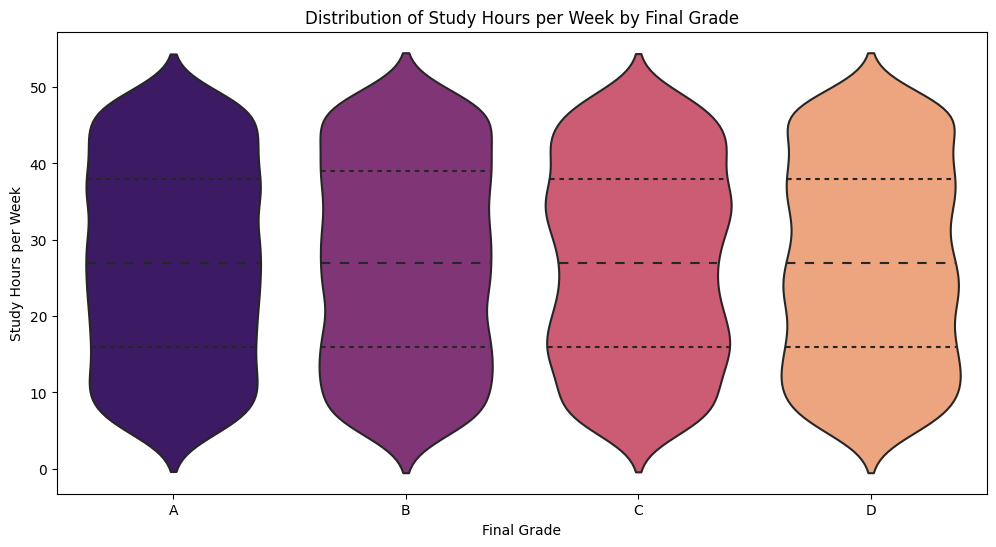

In [18]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='Final_Grade', y='Study_Hours_per_Week', data=df, palette='magma', inner="quartile")
plt.title('Distribution of Study Hours per Week by Final Grade')
plt.xlabel('Final Grade')
plt.ylabel('Study Hours per Week')
plt.show()

In [19]:
pip install joypy

Note: you may need to restart the kernel to use updated packages.


<Figure size 1200x800 with 0 Axes>

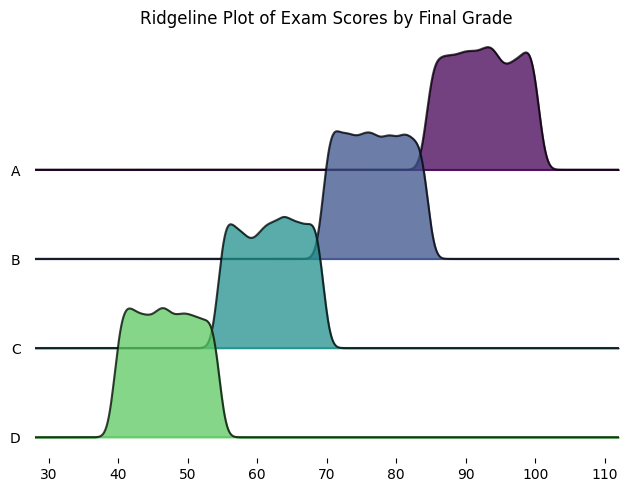

In [20]:
import joypy

plt.figure(figsize=(12, 8))
joypy.joyplot(data=df, by='Final_Grade', column='Exam_Score (%)', colormap=plt.cm.viridis, alpha=0.75)
plt.title('Ridgeline Plot of Exam Scores by Final Grade')
plt.show()


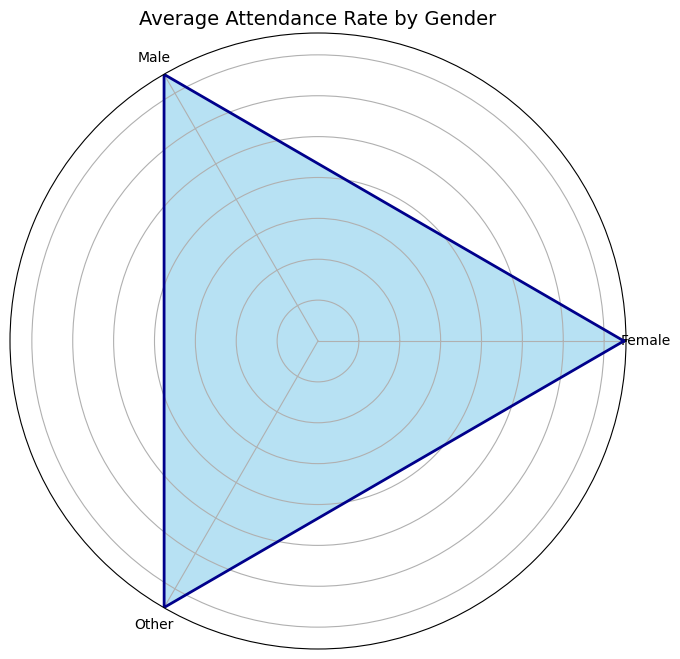

In [21]:
from math import pi

# Group by Gender and calculate mean attendance rate
gender_attendance = df.groupby('Gender')['Attendance_Rate (%)'].mean().reset_index()

# Extract categories and values
categories = list(gender_attendance['Gender'])
values = list(gender_attendance['Attendance_Rate (%)'])

# Compute angles for the circular chart
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]

# Ensure circular closure by repeating first value and first angle
values.append(values[0])
angles.append(angles[0])

# Create the radial bar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.fill(angles, values, color='skyblue', alpha=0.6)
ax.plot(angles, values, color='darkblue', linewidth=2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticklabels([])
plt.title("Average Attendance Rate by Gender", fontsize=14)
plt.show()


<Figure size 1400x1000 with 0 Axes>

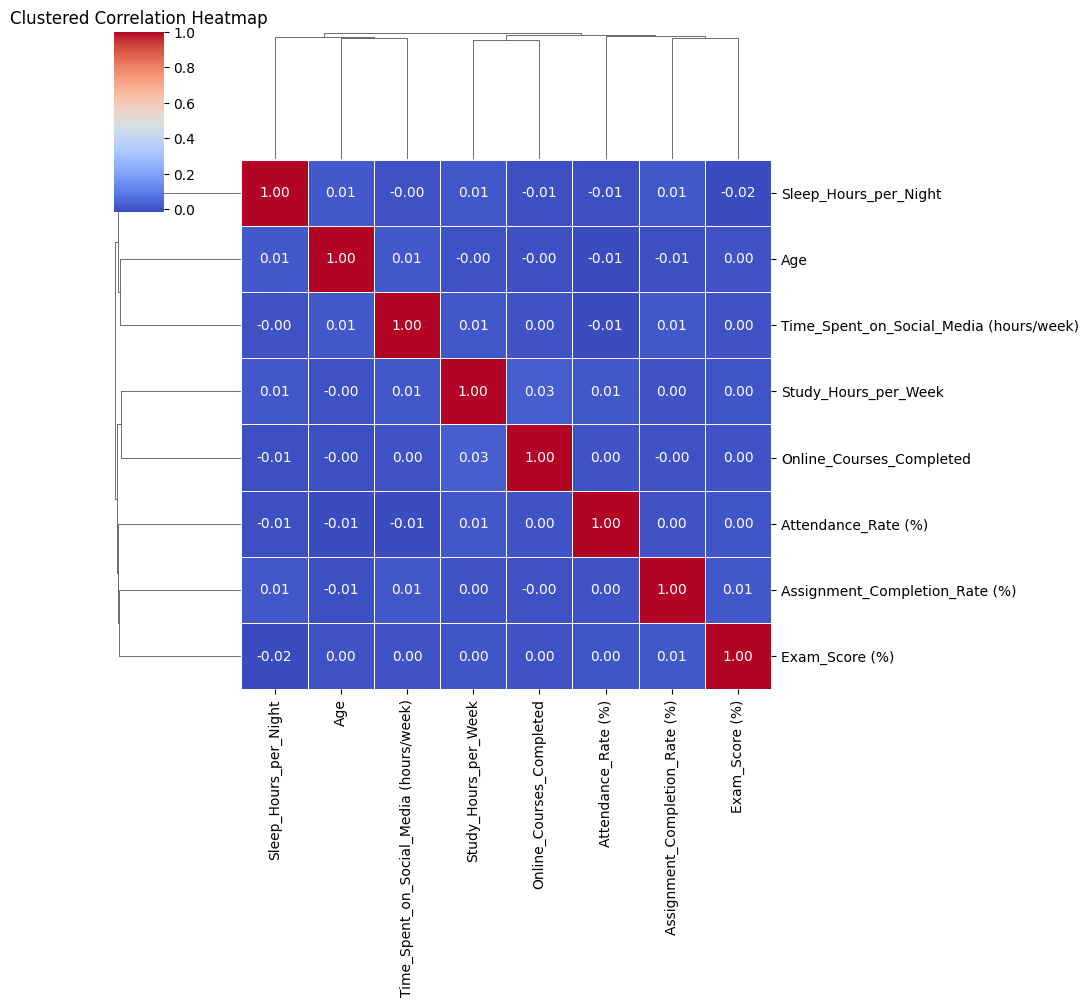

In [22]:
import numpy as np

# Selecting only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()

# Create a clustered heatmap
sns.clustermap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, method='ward')
plt.title('Clustered Correlation Heatmap')
plt.show()


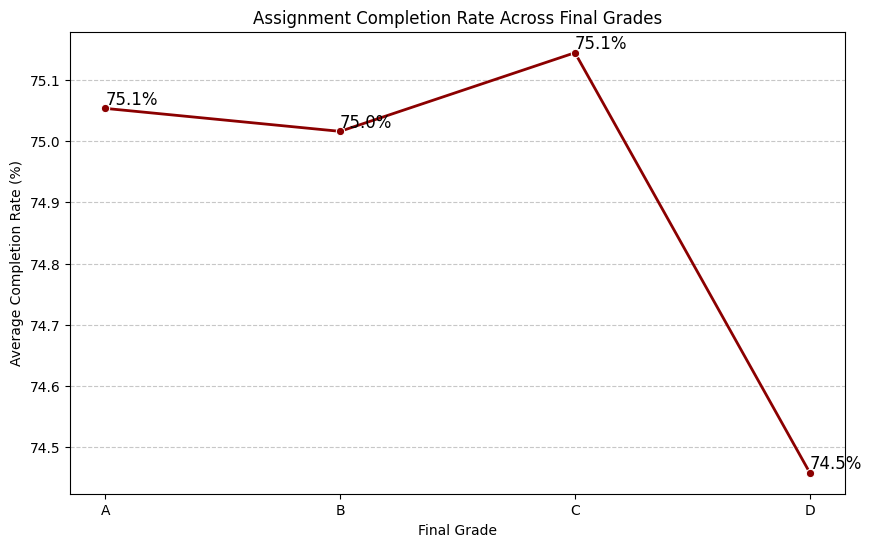

In [23]:
pivot_df = df.groupby('Final_Grade')['Assignment_Completion_Rate (%)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Final_Grade', y='Assignment_Completion_Rate (%)', data=pivot_df, marker="o", color="darkred", linewidth=2)
for index, row in pivot_df.iterrows():
    plt.text(row['Final_Grade'], row['Assignment_Completion_Rate (%)'], f"{row['Assignment_Completion_Rate (%)']:.1f}%", 
             verticalalignment='bottom', fontsize=12, color='black')

plt.title('Assignment Completion Rate Across Final Grades')
plt.xlabel('Final Grade')
plt.ylabel('Average Completion Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## EDA

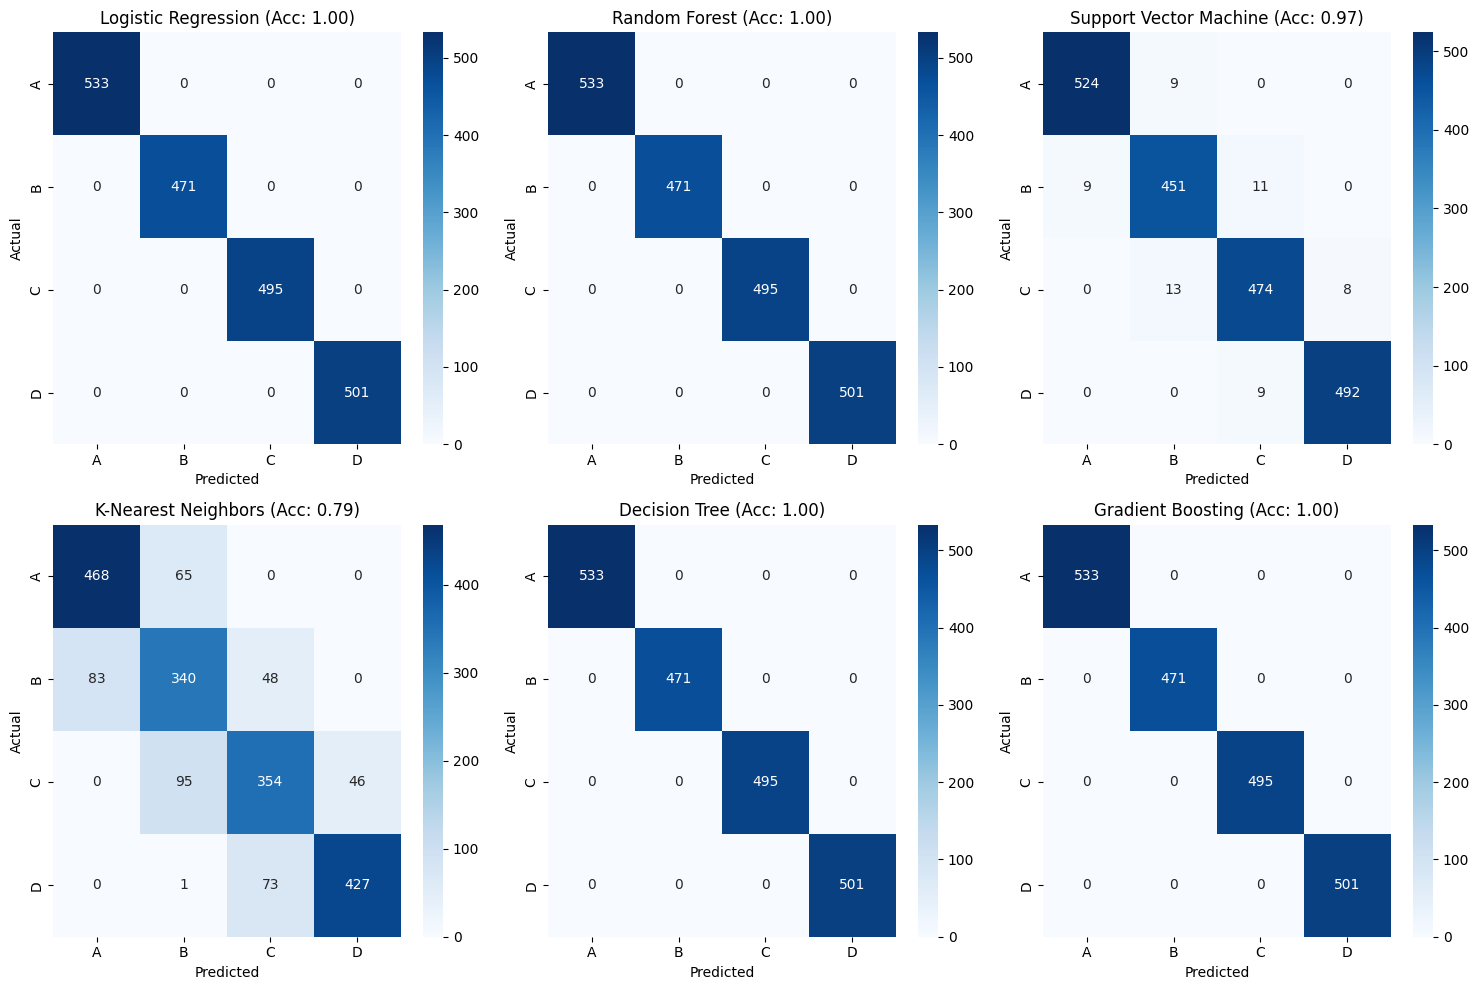

Logistic Regression: 1.00
Random Forest: 1.00
Decision Tree: 1.00
Gradient Boosting: 1.00
Support Vector Machine: 0.97
K-Nearest Neighbors: 0.79


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

features = ['Age', 'Study_Hours_per_Week', 'Online_Courses_Completed', 
            'Assignment_Completion_Rate (%)', 'Exam_Score (%)', 
            'Attendance_Rate (%)', 'Time_Spent_on_Social_Media (hours/week)', 'Sleep_Hours_per_Night']

X = df[features]
y = df['Final_Grade']

# Splitting dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features (important for SVM & Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# List of classifiers to apply
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}
plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    # Confusion Matrix Plot
    plt.subplot(2, 3, i)
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f"{name} (Acc: {acc:.2f})")

plt.tight_layout()
plt.show()

sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for name, acc in sorted_results:
    print(f"{name}: {acc:.2f}")

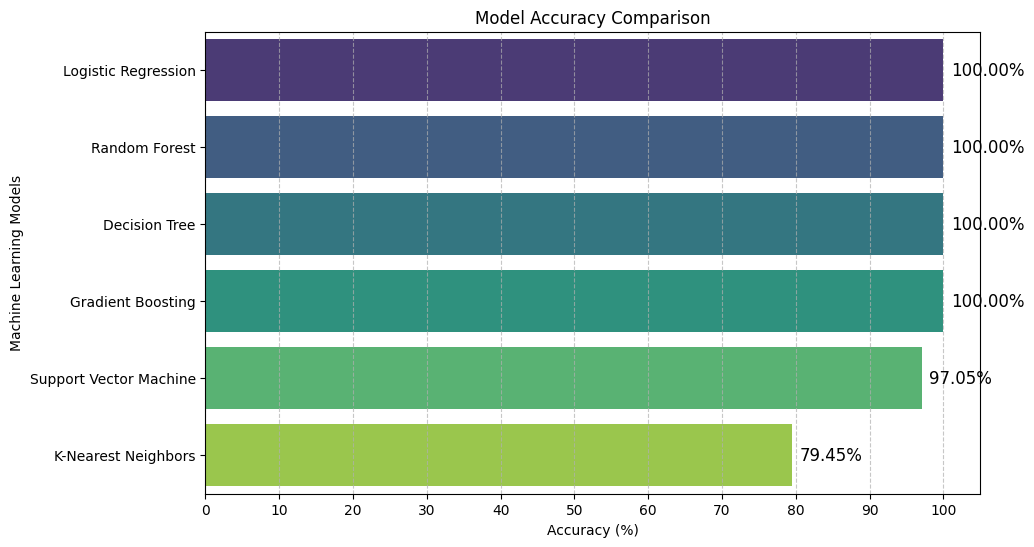

In [25]:
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

# Extract model names and their accuracy values
model_names = [name for name, acc in sorted_results]
accuracy_values = [acc * 100 for _, acc in sorted_results]  # Convert to percentage

# Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=accuracy_values, y=model_names, palette="viridis")

# Labeling
plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Models")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 105)  # Keep max at 105 for better spacing
plt.xticks(range(0, 101, 10))
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display values on bars
for index, value in enumerate(accuracy_values):
    plt.text(value + 1, index, f"{value:.2f}%", va='center', fontsize=12)

plt.show()


## Thank you..upvote pls...!!!